# Artifacts quick inspection

Inspection of the artifacts in `data/derived`

## Lesion Matrices

### `lesion_matrix/21-07_s1.1`

#### Loading

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

deriv_dir = "/home/etosato/Projects/NEMESIS_fs/data/derived/lesion_matrix/21-07_run1"

In [2]:
# Load Manifest
manifest_path = os.path.join(deriv_dir, "manifest.json")
with open(manifest_path, "r") as f:
    manifest = json.load(f)

print("Manifest:")
print(json.dumps(manifest, indent=2))

In [3]:
# Load Metadata
metadata_path = os.path.join(deriv_dir, "metadata.csv")
df_meta = pd.read_csv(metadata_path)

print(f"\nMetadata shape: {df_meta.shape}")
display(df_meta.head())

FileNotFoundError: [Errno 2] No such file or directory: '/home/etosato/Projects/NEMESIS_fs/data/derived/lesion_matrix/21-07_run1/metadata.csv'

In [4]:
# Load Matrix
matrix_path = os.path.join(deriv_dir, "matrix.npy")
matrix = np.load(matrix_path)

print(f"Matrix shape: {matrix.shape}")
print(f"Matrix dtype: {matrix.dtype}")
print(f"Sparsity (fraction of non-zeros): {np.count_nonzero(matrix) / matrix.size:.4f}")

In [5]:
# Load Non-constant Mask
mask_path = os.path.join(deriv_dir, "non_constant_mask.npy")
if os.path.exists(mask_path):
    mask = np.load(mask_path)
    print(f"Non-constant mask shape: {mask.shape}")
    print(f"Non-constant mask sum: {mask.sum()}")
else:
    print("Non-constant mask not found.")

Non-constant mask not found.


#### Basic Exploration

In [6]:
# Dataset distribution
if 'dataset' in df_meta.columns:
    df_meta['dataset'].value_counts().plot(kind='bar', title='Subjects per Dataset', color='skyblue', edgecolor='black')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Dataset column not found in metadata")

In [7]:
# Lesion load distribution (sum of lesion voxels per subject)
lesion_loads = matrix.sum(axis=1)
plt.hist(lesion_loads, bins=50, edgecolor='black', color='salmon')
plt.title('Distribution of Lesion Loads (voxels/features per subject)')
plt.xlabel('Lesion Volume (features)')
plt.ylabel('Number of Subjects')
plt.show()

## Masked FC matrices

**Contesto**: `mask_fc.py` + `build_fc_matrix.py` sono già girati su tutta la coorte WashU (169 pazienti, atlante `Yan200TianS2Buckner7N`). Per ogni paziente, se la sua lesione copre troppo un nodo cerebrale (soglia standard 50%, vedi `notebooks/fc_lesion_masking.ipynb`), quel nodo viene marcato come compromesso e le sue connessioni diventano `NaN` nella matrice finale.

**Quello che manca**: oggi la matrice finale include tutti i 169 pazienti, senza escludere nessuno — anche chi ha moltissimi nodi compromessi. Questa sezione serve a guardare i dati reali prima di decidere se/dove fissare una soglia di esclusione paziente.

### `mask_summary.csv` — quanti nodi sono compromessi, per paziente

Questo file dice, per ognuno dei 169 pazienti, quanti nodi (su 239 totali della mappa cerebrale) hanno una lesione troppo estesa per fidarsi della loro connettività.

#### Loading

In [3]:
fc_base_dir = "/Users/emmatosato/Local Projects/PhD/NEMESIS_fs/data/derived/features"
atlas_combo = "Yan200TianS2Buckner7N"
n_total_nodes = 239  # nodi totali di questa mappa cerebrale (Yan200 corticali + Tian S2 subcorticali + Buckner7N cervelletto)

mask_summary_path = os.path.join(fc_base_dir, "masked_fc", atlas_combo, "mask_summary.csv")
df_mask_summary = pd.read_csv(mask_summary_path)

print(f"Pazienti nel run reale: {len(df_mask_summary)}")
display(df_mask_summary.head())
display(df_mask_summary["n_compromised_nodes"].describe())

Pazienti nel run reale: 169


,subject_id,n_compromised_nodes
0,sub-STUNIPD0002,0
1,sub-STUNIPD0003,8
2,sub-STUNIPD0005,2
3,sub-STUNIPD0006,9
4,sub-STUNIPD0008,0


count    169.000000
mean       3.881657
std        6.705379
min        0.000000
25%        0.000000
50%        1.000000
75%        5.000000
max       42.000000
Name: n_compromised_nodes, dtype: float64

#### Distribuzione: la maggior parte dei pazienti ha pochissimi nodi compromessi

Se la distribuzione fosse piatta (tanti pazienti sparsi su tutti i valori), una soglia sarebbe una scelta delicata. Guardiamo se invece c'è una massa di pazienti "puliti" e una coda di pochi pazienti molto compromessi — in quel caso la soglia taglierebbe solo la coda, con poco rischio di perdere dati buoni.

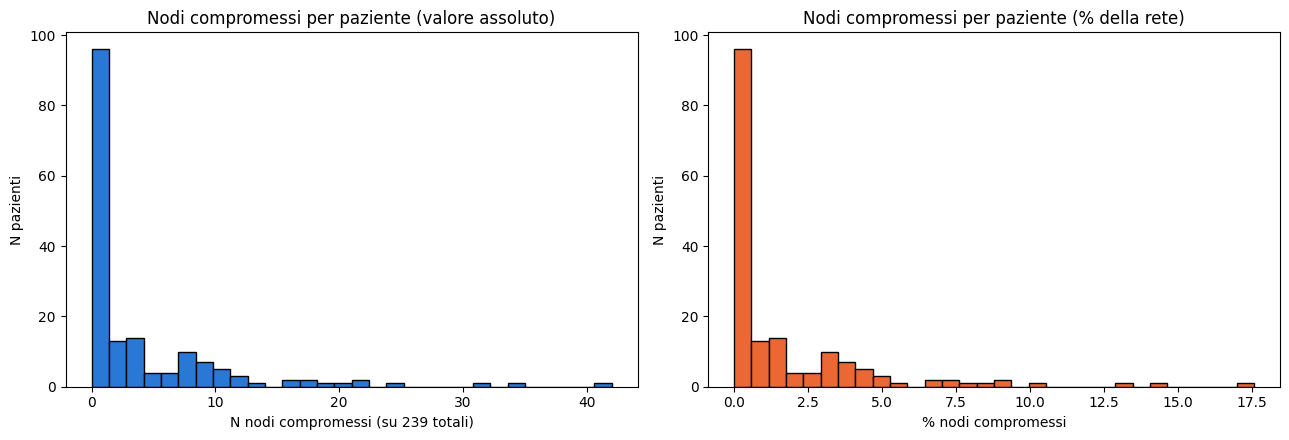

p50      1.00
p75      5.00
p90     11.00
p95     17.60
p99     31.96
p100    42.00
Name: n_compromised_nodes, dtype: float64

In [9]:
SERIES_BLUE = "#2a78d6"
SERIES_ORANGE = "#eb6834"

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df_mask_summary["n_compromised_nodes"], bins=30, edgecolor="black", color=SERIES_BLUE)
axes[0].set_title("Nodi compromessi per paziente (valore assoluto)")
axes[0].set_xlabel(f"N nodi compromessi (su {n_total_nodes} totali)")
axes[0].set_ylabel("N pazienti")

axes[1].hist(df_mask_summary["n_compromised_nodes"] / n_total_nodes * 100, bins=30, edgecolor="black", color=SERIES_ORANGE)
axes[1].set_title("Nodi compromessi per paziente (% della rete)")
axes[1].set_xlabel("% nodi compromessi")
axes[1].set_ylabel("N pazienti")

plt.tight_layout()
plt.show()

percentiles = [50, 75, 90, 95, 99, 100]
pct_table = df_mask_summary["n_compromised_nodes"].quantile([p / 100 for p in percentiles])
pct_table.index = [f"p{p}" for p in percentiles]
display(pct_table.rename("n_compromised_nodes"))

#### Quanti pazienti perderesti, a seconda di dove metti la soglia

Invece di guardare un solo numero, vediamo l'intera curva: per ogni soglia possibile (n nodi compromessi oltre cui un paziente verrebbe escluso), quanti pazienti restano fuori.

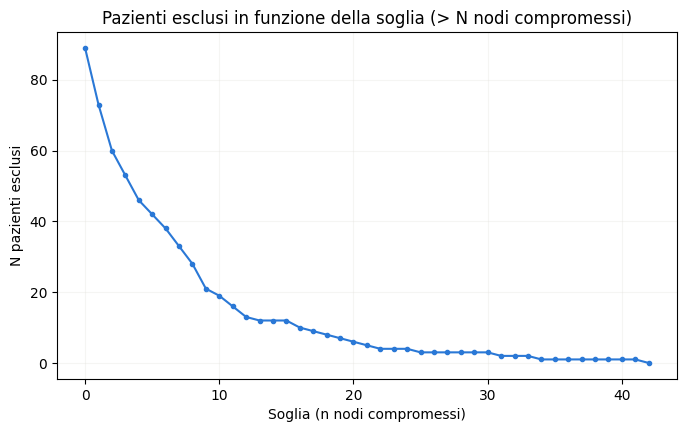

,soglia_nodi,soglia_%_rete,pazienti_esclusi,pazienti_rimasti
0,5,2.1,42,127
1,10,4.2,19,150
2,12,5.0,13,156
3,15,6.3,12,157
4,20,8.4,6,163
5,24,10.0,4,165
6,30,12.6,3,166
7,40,16.7,1,168


In [10]:
n_patients = len(df_mask_summary)
max_nodes = int(df_mask_summary["n_compromised_nodes"].max())
thresholds = np.arange(0, max_nodes + 1)
n_excluded = [(df_mask_summary["n_compromised_nodes"] > thr).sum() for thr in thresholds]

plt.figure(figsize=(8, 4.5))
plt.plot(thresholds, n_excluded, marker="o", markersize=3, color=SERIES_BLUE)
plt.title("Pazienti esclusi in funzione della soglia (> N nodi compromessi)")
plt.xlabel("Soglia (n nodi compromessi)")
plt.ylabel("N pazienti esclusi")
plt.grid(alpha=0.3, color="#e1e0d9")
plt.show()

candidate_thresholds = [5, 10, 12, 15, 20, 24, 30, 40]
summary_df = pd.DataFrame({
    "soglia_nodi": candidate_thresholds,
    "soglia_%_rete": [round(t / n_total_nodes * 100, 1) for t in candidate_thresholds],
    "pazienti_esclusi": [(df_mask_summary["n_compromised_nodes"] > t).sum() for t in candidate_thresholds],
})
summary_df["pazienti_rimasti"] = n_patients - summary_df["pazienti_esclusi"]
display(summary_df)

### Un nodo compromesso costa più di 1 connessione

Un dettaglio che rischia di sfuggire guardando solo il conteggio dei nodi: se un nodo è compromesso, **tutte** le sue connessioni con il resto della rete diventano NaN — fino a 238 connessioni perse per un solo nodo (su una rete di 239). Quindi "3 nodi compromessi" può voler dire poche decine di NaN o molte centinaia, a seconda di quali nodi sono coinvolti. Guardiamo la relazione reale tra nodi compromessi e % di connessioni perse nella matrice finale, per capire se contare i nodi è già una buona proxy o se serve guardare direttamente i NaN.

Matrice FC finale: 169 pazienti x 28441 connessioni
Frazione NaN sull'intera matrice: 0.0356


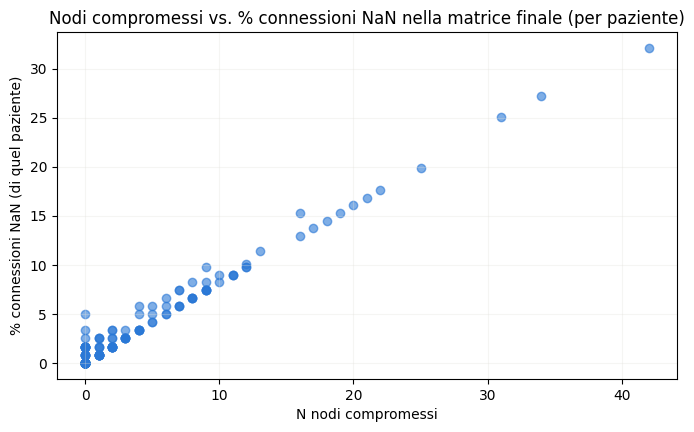

,subject_id,nan_edge_fraction_%,n_compromised_nodes
74,sub-STUNIPD0105,32.119124,42
73,sub-STUNIPD0104,27.196653,34
98,sub-STUNIPD0150,25.034281,31
133,sub-STUNIPD0202,19.865687,25
167,sub-STUNIPD0248,17.597834,22
168,sub-STUNIPD0250,16.834851,21
156,sub-STUNIPD0234,16.068352,20
134,sub-STUNIPD0203,15.298337,19
75,sub-STUNIPD0109,14.524806,18
163,sub-STUNIPD0242,13.747759,17


In [11]:
fc_matrix_dir = os.path.join(fc_base_dir, "fc_matrix", atlas_combo, "24-07_s1")

fc_matrix = np.load(os.path.join(fc_matrix_dir, "matrix.npy"))
df_fc_meta = pd.read_csv(os.path.join(fc_matrix_dir, "metadata.csv"))

print(f"Matrice FC finale: {fc_matrix.shape[0]} pazienti x {fc_matrix.shape[1]} connessioni")
print(f"Frazione NaN sull'intera matrice: {np.isnan(fc_matrix).mean():.4f}")

nan_fraction_per_subject = np.isnan(fc_matrix).mean(axis=1) * 100
df_nan = df_fc_meta.copy()
df_nan["nan_edge_fraction_%"] = nan_fraction_per_subject
df_nan = df_nan.merge(df_mask_summary, on="subject_id", how="left")

plt.figure(figsize=(8, 4.5))
plt.scatter(df_nan["n_compromised_nodes"], df_nan["nan_edge_fraction_%"], alpha=0.6, color=SERIES_BLUE)
plt.title("Nodi compromessi vs. % connessioni NaN nella matrice finale (per paziente)")
plt.xlabel("N nodi compromessi")
plt.ylabel("% connessioni NaN (di quel paziente)")
plt.grid(alpha=0.3, color="#e1e0d9")
plt.show()

display(df_nan.sort_values("n_compromised_nodes", ascending=False).head(10))